## 1 · Imports

In [1]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [2]:
import mudata as mu

In [3]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


## 2 · Data Loading

Load mudata

In [4]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/002_annotate_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

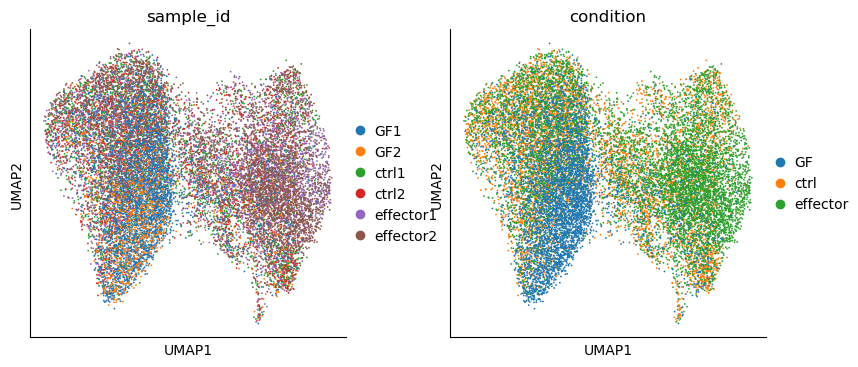

In [5]:
sc.pl.umap(mdata["gex"], color =["sample_id","condition"])

## 3 · Metadata mapping

Load mudata

In [ ]:
mapping = {
    "10mix_ICI1": "ctrl",
    "10mix_ICI2": "ctrl",
    "11mix_ICI1": "effector",
    "11mix_ICI2": "effector",
    "GF_ICI1": "GF_noICI",
    "GF_ICI2": "GF_noICI",
    "GF_ICI1_plus": "GF",
    "GF_ICI2_plus": "GF",
}

mdata["gex"].obs["group4"] = mdata["gex"].obs["sample_id"].map(mapping)

In [ ]:
mapping = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noICI1",
    "GF_ICI2": "GF_noICI2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2",
}

mdata["gex"].obs["sample_id"] = mdata["gex"].obs["sample_id"].map(mapping)

In [ ]:
desired_order = [
    "effector",
    "ctrl",
    "GF",
    "GF_noici",
]

mdata["gex"].obs["group4"] = pd.Categorical(
    mdata["gex"].obs["group4"], categories=desired_order, ordered=True
)

## 4 · Gene marker ploting


In [ ]:
import scanpy as sc


def plot_marker_umaps(adata, marker_dict, title_prefix):
    for category, genes in marker_dict.items():
        genes = sorted(list(genes))
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            print(f"No genes found for {category}")
            continue

        print(f"Plotting {category}: {genes_present}")

        sc.pl.umap(
            adata,
            color=genes_present,
            ncols=4,
            cmap="Reds",
            vmax="p99",
            title=[f"{title_prefix} | {category} | {g}" for g in genes_present],
            frameon=False,
        )

In [6]:
gene_markers = {
    "Activated": {
        "Ccl5",
        "Ctla2a",
        "Cd44",
        "Tbx21",
    },
    "Cycling": {"Mki67", "Top2a", "Pclaf"},
    "Effector_memory": {"Gzmk", "Cxcr3"},
    "Exhausted": {
        "Tox","Pdcd1","Havcr2",
    },
    "Stem/Resident_memory": {"Klf2", "Tcf7", "Foxp1", "Lef1", "Bach2", "Sell"},
}

In [ ]:
gene_markers

In [ ]:
plot_marker_umaps(
    adata=mdata["gex"],
    marker_dict=gene_markers,title_prefix = "Gene markers"
)

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["Tcf7", "Slamf6", "Pdcd1"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["Cd44", "Sell"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

## 5 · Annotation


In [ ]:
# Check unique clusters first (optional, but recommended)
print(mdata["gex"].obs["rna_leiden_05"].unique())

# Create mapping dictionary (adjust numbers if needed)
cluster_annotation = {
    "0": "Activated",
    "1": "Stem/Resident_memory",
    "2": "Effector_memory",
    "3": "Stem/Resident_memory",
    "4": "Exhausted",
    "5": "Activated",
    "6": "Activated",
    "7": "Cycling",
}

# If gex03 is integer instead of string, remove the quotes in dictionary keys
# e.g., 0: "Activated"

# Create new annotation column
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["rna_leiden_05"].map(cluster_annotation)
)

# Make it categorical (recommended for plotting)
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["cell_annotation_05"].astype("category")
)

# Verify
print(mdata["gex"].obs[["rna_leiden_05", "cell_annotation_05"]].head())

In [ ]:
sc.pl.umap(
    mdata["gex"], color="cell_annotation_05", frameon=False, legend_loc="on data"
)

## 6 · Dotplot


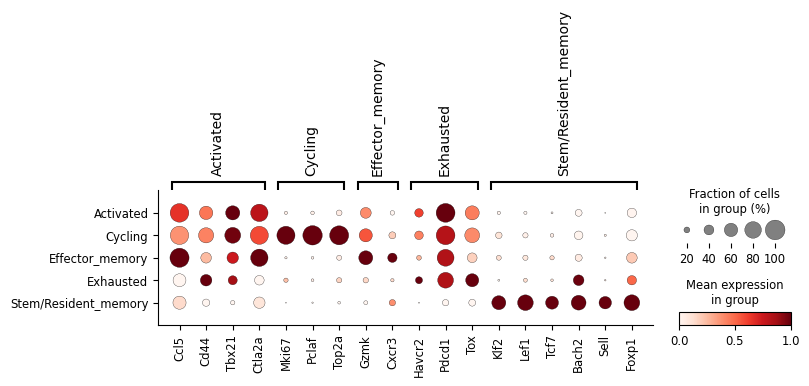

In [7]:
from matplotlib import cm


sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  # ,save="annotation.svg"
)

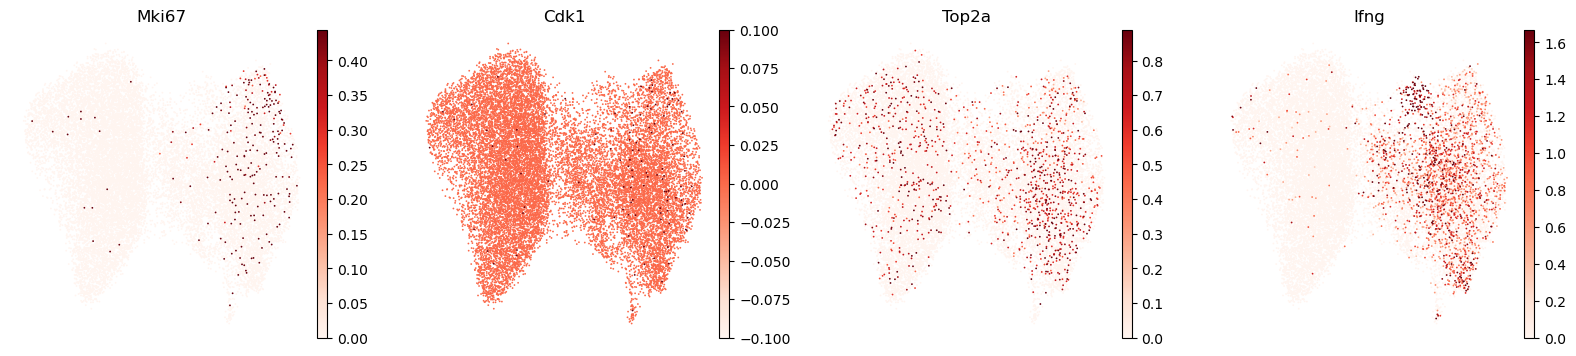

In [7]:
sc.pl.umap(
    mdata["gex"],
    color=["Mki67", "Cdk1", "Top2a","Ifng"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False
)

## 6 · Umap by sample


In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["group4"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF_noICI1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF_noICI2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["ctrl1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["ctrl2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["effector1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["effector2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
#mdata.write_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

In [ ]:
#mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

In [ ]:
#adata = mdata["gex"]

In [ ]:
#adata.write_h5ad("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_adata.h5ad")

## Cell cycle genes

In [9]:
from __future__ import annotations

import zipfile

import pooch
import scanpy as sc


sc.logging.print_header()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  and (v := getattr(pkg, "__version__", None))


Package,Version
torch,2.6.0
ipywidgets,8.1.8
palantir,1.4.2
pooch,1.8.2 (v1.8.2)
Component,Info
Python,"3.10.18 | packaged by conda-forge | (main, Jun 4 2025, 14:45:41) [GCC 13.3.0]"
OS,Linux-5.14.0-687.10.1.el9_8.0.1.x86_64-x86_64-with-glibc2.34
CPU,"144 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA A40, Driver: 610.43.02, Memory: 46068 MiB"
GPU,"ID: 1, NVIDIA A40, Driver: 610.43.02, Memory: 46068 MiB"


In [10]:
p_zip = pooch.retrieve(
    "https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1",
    known_hash="sha256:6557fe2a2761d1550d41edf61b26c6d5ec9b42b4933d56c3161164a595f145ab",
    path="../data",
)

In [11]:
with zipfile.ZipFile(p_zip, "r") as f_zip:
    f_csv = zipfile.Path(f_zip, "nestorawa_forcellcycle_expressionMatrix.txt").open()
    adata = sc.read_csv(f_csv, delimiter="\t").T
    cell_cycle_genes = zipfile.Path(f_zip, "regev_lab_cell_cycle_genes.txt").read_text().splitlines()

In [12]:
s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]
cell_cycle_genes = [*s_genes, *g2m_genes]

In [13]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    s_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_s_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_s_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_s_genes.append(item['query'].capitalize())

print(mouse_s_genes)

2026-08-11 09:13:58 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:13:58 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:13:59 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-11 09:14:00 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:00 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/17218?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:00 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:00 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/18538?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:00 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:01 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/22171?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:01 | [WA

['Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2', 'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Hells', 'Rfc2', 'Rpa2', 'Nasp', 'Rad51ap1', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7', 'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1', 'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pola1', 'Chaf1b', 'Brip1', 'E2f8']


In [14]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    g2m_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_g2m_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_g2m_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_g2m_genes.append(item['query'].capitalize())

print(mouse_g2m_genes)

2026-08-11 09:14:09 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:09 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:10 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-11 09:14:11 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:11 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/97165?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:11 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:11 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/12534?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:11 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:11 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/108907?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:11 | [W

['Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80', 'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a', 'Smc4', 'Ccnb2', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e', 'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk', 'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8', 'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5', 'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa']


In [15]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    cell_cycle_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_cell_cycle_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_cell_cycle_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_cell_cycle_genes.append(item['query'].capitalize())

print(mouse_cell_cycle_genes)

2026-08-11 09:14:21 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:21 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:22 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-11 09:14:23 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:23 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/17218?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:23 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:23 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/18538?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:23 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-11 09:14:23 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/22171?fields=symbol "HTTP/1.1 200 OK"
2026-08-11 09:14:23 | [WA

['Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2', 'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Hells', 'Rfc2', 'Rpa2', 'Nasp', 'Rad51ap1', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7', 'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1', 'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pola1', 'Chaf1b', 'Brip1', 'E2f8', 'Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80', 'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a', 'Smc4', 'Ccnb2', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e', 'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk', 'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8', 'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5', 'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa']


In [16]:
sc.pp.filter_cells(mdata["gex"], min_genes=200)
sc.pp.filter_genes(mdata["gex"], min_cells=3)
sc.pp.normalize_total(mdata["gex"], target_sum=1e4)

In [17]:
sc.pp.log1p(mdata["gex"])

adata.X seems to be already log-transformed.


In [18]:
sc.tl.score_genes_cell_cycle(mdata["gex"], s_genes=mouse_s_genes, g2m_genes=mouse_g2m_genes)

genes are not in var_names and ignored: Index(['Fam64a', 'Hn1'], dtype='object')


In [19]:
mdata["gex"].obs

,sample_id,condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,...,n_genes,rna_leiden,doublet_score,predicted_doublet,rna_leiden_12,rna_leiden_2,cell_annotation_05,S_score,G2M_score,phase
AAACCTGAGTCTTGCA-1_10mix1,ctrl1,ctrl,1889,7.544332,6162.0,8.726319,18.954885,215.0,5.375278,3.489127,...,1889,1,0.097625,False,0,4,Naive,-0.066909,-0.035769,G1
AAACCTGAGTTAAGTG-1_10mix1,ctrl1,ctrl,1140,7.039660,2870.0,7.962416,20.278746,94.0,4.553877,3.275261,...,1140,1,0.137871,False,0,10,Naive,-0.000334,0.036960,G2M
AAACCTGCAGGATCGA-1_10mix1,ctrl1,ctrl,1980,7.591357,6246.0,8.739857,16.330451,176.0,5.176150,2.817803,...,1979,6,0.069388,False,7,12,Effector_memory,-0.034775,0.019074,G2M
AAACCTGCATAACCTG-1_10mix1,ctrl1,ctrl,1387,7.235619,3585.0,8.184793,20.055788,142.0,4.962845,3.960948,...,1386,5,0.065880,False,5,5,Activated,-0.026726,-0.002404,G1
AAACCTGCATACCATG-1_10mix1,ctrl1,ctrl,1707,7.443078,3830.0,8.250881,16.057441,148.0,5.003946,3.864230,...,1706,3,0.033079,False,8,11,Effector_memory,0.075558,-0.039301,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCTCGGTGTTA-1_GF2,GF2,GF,1302,7.172425,3814.0,8.246696,20.346093,144.0,4.976734,3.775564,...,1302,0,0.121387,False,4,2,Naive,0.098368,-0.041305,S
TTTGTCAAGGCTAGCA-1_GF2,GF2,GF,1981,7.591862,6128.0,8.720787,16.416449,196.0,5.283204,3.198433,...,1981,4,0.121387,False,3,15,Activated,-0.054024,0.044070,G2M
TTTGTCAAGTGCCAGA-1_GF2,GF2,GF,1337,7.198931,3667.0,8.207402,20.998091,140.0,4.948760,3.817835,...,1337,1,0.107050,False,4,2,Naive,-0.080005,-0.059467,G1
TTTGTCAAGTTGTCGT-1_GF2,GF2,GF,1191,7.083388,3008.0,8.009363,18.683511,119.0,4.787492,3.956117,...,1191,1,0.161765,False,0,8,Naive,0.052897,-0.015835,S


... storing 'phase' as categorical


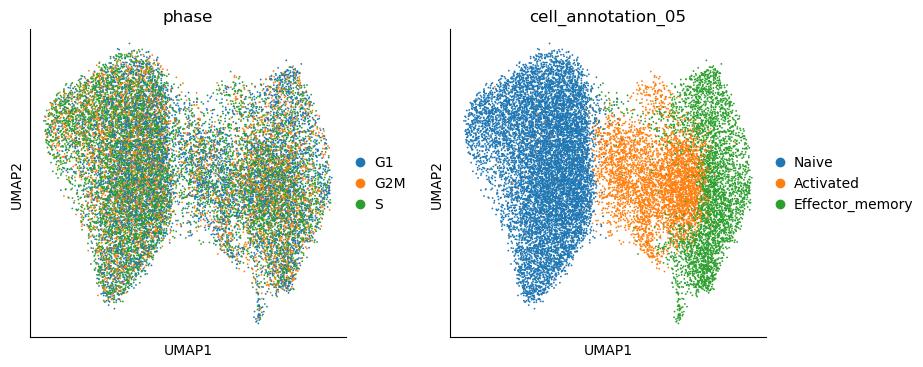

In [20]:
sc.pl.umap(mdata["gex"], color = ["phase","cell_annotation_05"])

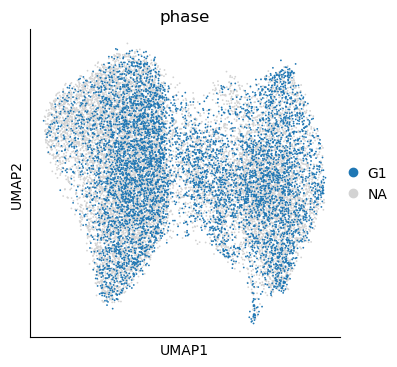

In [21]:
sc.pl.umap(mdata["gex"], color = "phase", groups="G1")

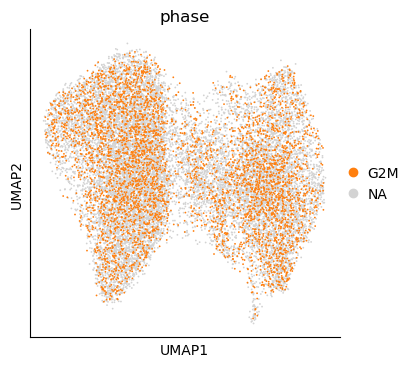

In [22]:
sc.pl.umap(mdata["gex"], color = "phase", groups="G2M")

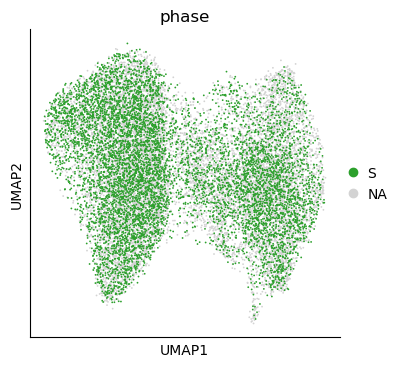

In [23]:
sc.pl.umap(mdata["gex"], color = "phase", groups="S")

Genes missing from dataset (2): {'Hn1', 'Fam64a'}


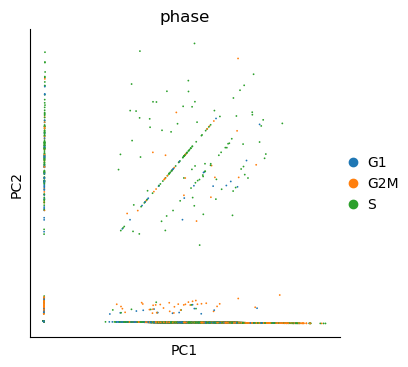

In [24]:
# 1. Filter to keep only cell cycle genes present in your GEX dataset
valid_cc_genes = [g for g in mouse_cell_cycle_genes if g in mdata["gex"].var_names]

# Print missing genes (optional, to verify which were dropped)
missing_genes = set(mouse_cell_cycle_genes) - set(valid_cc_genes)
print(f"Genes missing from dataset ({len(missing_genes)}): {missing_genes}")

# 2. Subset the AnnData object using the validated list
adata_cc_genes = mdata["gex"][:, valid_cc_genes].copy()

# 3. Run PCA
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [25]:
sc.pp.regress_out(mdata["gex"], ["S_score", "G2M_score"])

Genes missing from dataset (2): {'Hn1', 'Fam64a'}


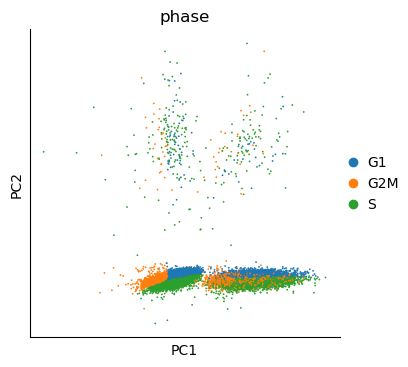

In [26]:
# 1. Filter to keep only cell cycle genes present in your GEX dataset
valid_cc_genes = [g for g in mouse_cell_cycle_genes if g in mdata["gex"].var_names]

# Print missing genes (optional, to verify which were dropped)
missing_genes = set(mouse_cell_cycle_genes) - set(valid_cc_genes)
print(f"Genes missing from dataset ({len(missing_genes)}): {missing_genes}")

# 2. Subset the AnnData object using the validated list
adata_cc_genes = mdata["gex"][:, valid_cc_genes].copy()

# 3. Run PCA
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [27]:
import numpy as np

# 1. Reference the GEX AnnData object
gex = mdata["gex"]

# 2. Extract Ifng expression array safely (handles sparse or dense matrices)
#ifng_expr = gex[:, "Ifng"].X.toarray().flatten() if hasattr(gex.X, "toarray") else gex[:, "Ifng"].X.flatten()

# 3. Combine conditions: (S or G2M phase) AND (Ifng > 0)
cycling_mask = gex.obs["phase"].isin(["S", "G2M"])# & (ifng_expr > 0)

# 4. Subset the AnnData or MuData object
cycling = gex[cycling_mask].copy()

In [28]:
mdata["gex"]

AnnData object with n_obs × n_vars = 18263 × 17944
    obs: 'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna

In [29]:
# 5. Recompute Neighborhood Graph
# Set n_pcs <= min(30, n_cells - 1) if your subset is very small
sc.pp.neighbors(cycling, n_neighbors=15, n_pcs=30)

# 6. Recompute UMAP Embedding
sc.tl.umap(cycling)

# 7. Recompute Clustering (Adjust resolution as needed: lower = fewer clusters)
sc.tl.leiden(cycling, resolution=0.5, key_added="leiden")



I0000 00:00:1786432511.696852 3256051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786432512.336015 3256051 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786432517.177310 3256051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/tmp/ipykernel_3256051/347087137.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead 

In [30]:
cycling

AnnData object with n_obs × n_vars = 12096 × 17944
    obs: 'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_lei

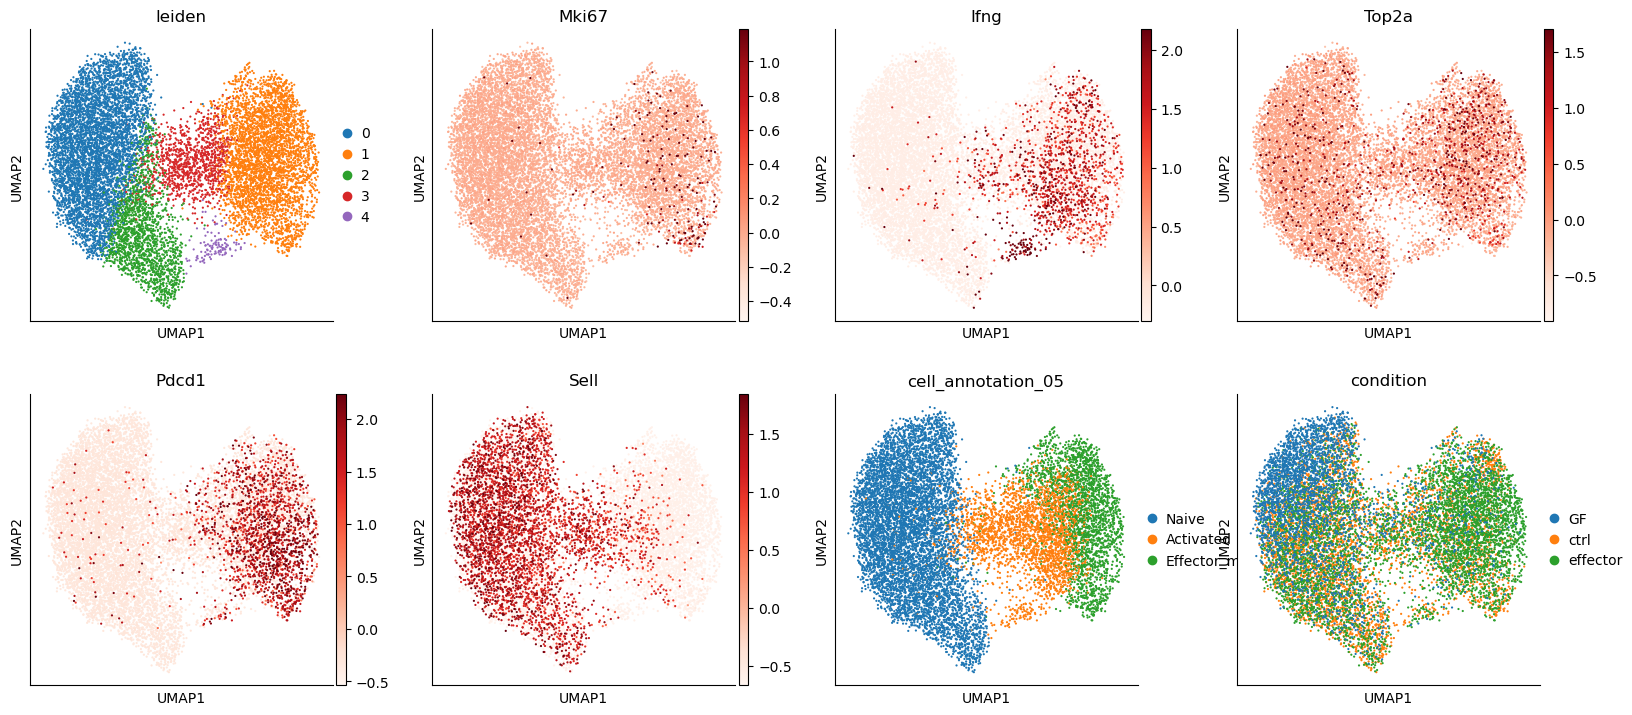

In [31]:
# 8. Visualize the new embedding
sc.pl.umap(cycling, color=["leiden","Mki67", "Ifng","Top2a","Pdcd1","Sell","cell_annotation_05","condition"], cmap="Reds", vmax="p99")

In [32]:
cycling

AnnData object with n_obs × n_vars = 12096 × 17944
    obs: 'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_lei

In [33]:
# Create a copy/subset containing only cells with expression > 0 for Ifng
mki67_pos_cells = cycling[cycling[:, "Mki67"].X.toarray().flatten() > 0] if hasattr(cycling.X, "toarray") else cycling[cycling[:, "Mki67"].X.flatten() > 0]

# Plot only expressing cells


In [34]:
sc.pl.violin(ifng_pos_cells, keys= ["Ifng","Mki67"], groupby="condition", cut=0)

NameError: name 'ifng_pos_cells' is not defined

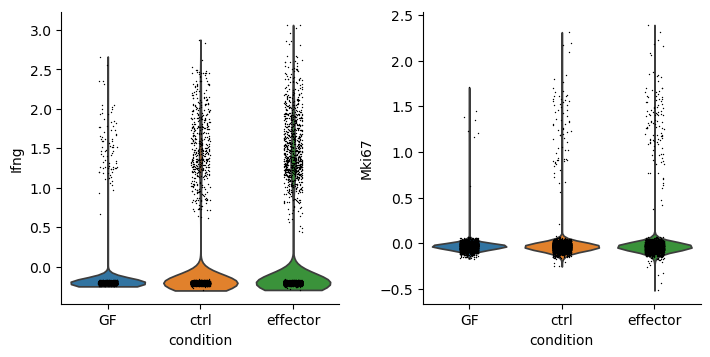

In [35]:
sc.pl.violin(cycling, ["Ifng","Mki67"], groupby="condition",cut=0)

saving figure to file figures/dotplot_dotplot_cycling_healhty.svg


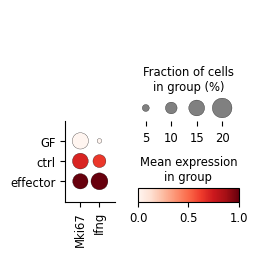

In [39]:
sc.pl.dotplot(cycling,["Mki67","Ifng"], groupby="condition",standard_scale="var")#, save = "dotplot_cycling_healhty.svg")

In [43]:
cycling.obs.condition

AAACCTGAGTTAAGTG-1_10mix1    ctrl
AAACCTGCAGGATCGA-1_10mix1    ctrl
AAACCTGCATACCATG-1_10mix1    ctrl
AAACCTGCATTGAGCT-1_10mix1    ctrl
AAACCTGTCGCCCTTA-1_10mix1    ctrl
                             ... 
TTTGCGCAGGGAGTAA-1_GF2         GF
TTTGCGCTCAACCATG-1_GF2         GF
TTTGCGCTCGGTGTTA-1_GF2         GF
TTTGTCAAGGCTAGCA-1_GF2         GF
TTTGTCAAGTTGTCGT-1_GF2         GF
Name: condition, Length: 12096, dtype: category
Categories (3, object): ['GF', 'ctrl', 'effector']

In [44]:
import numpy as np

# Extract expression vectors
ifng_expr = cycling[:, "Ifng"].X
mki67_expr = cycling[:, "Mki67"].X

# Handle sparse matrix format safely
if hasattr(ifng_expr, "toarray"):
    ifng_expr = ifng_expr.toarray().flatten()
    mki67_expr = mki67_expr.toarray().flatten()
else:
    ifng_expr = ifng_expr.flatten()
    mki67_expr = mki67_expr.flatten()

# Create boolean mask for double-positive cells
double_pos_mask = (ifng_expr > 0) & (mki67_expr > 0)

# Subset the cycling AnnData object
cycling_ifng_mki67 = cycling[double_pos_mask].copy()

print(
    f"Total cycling cells: {cycling.n_obs} | Double positive: {cycling_ifng_mki67.n_obs}"
)

Total cycling cells: 12096 | Double positive: 270


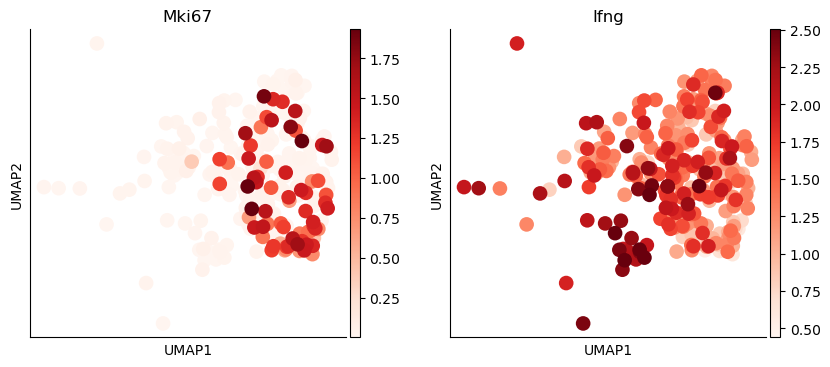

In [46]:
sc.pl.umap(cycling_ifng_mki67,color= ["Mki67","Ifng"], cmap="Reds", vmax="p99")

In [47]:
import numpy as np
import pandas as pd

# 1. Extract expression vectors safely handling sparse matrices
ifng_expr = cycling[:, "Ifng"].X
mki67_expr = cycling[:, "Mki67"].X

if hasattr(ifng_expr, "toarray"):
    ifng_expr = ifng_expr.toarray().flatten()
    mki67_expr = mki67_expr.toarray().flatten()
else:
    ifng_expr = ifng_expr.flatten()
    mki67_expr = mki67_expr.flatten()

# 2. Mask for double-positive cells
double_pos_mask = (ifng_expr > 0) & (mki67_expr > 0)

# 3. Subset the cycling AnnData object
cycling_dp = cycling[double_pos_mask].copy()

# 4. Number of cells per condition
cell_counts = cycling_dp.obs["condition"].value_counts()
print("--- Cell Counts (Ifng+ Mki67+) ---")
print(cell_counts)

# 5. Extract expression into a DataFrame for mean calculation
df_dp = pd.DataFrame(
    {
        "condition": cycling_dp.obs["condition"],
        "Ifng": cycling_dp[:, "Ifng"].X.toarray().flatten()
        if hasattr(cycling_dp.X, "toarray")
        else cycling_dp[:, "Ifng"].X.flatten(),
        "Mki67": cycling_dp[:, "Mki67"].X.toarray().flatten()
        if hasattr(cycling_dp.X, "toarray")
        else cycling_dp[:, "Mki67"].X.flatten(),
    }
)

# 6. Mean expression values in each condition
mean_expr = df_dp.groupby("condition")[["Ifng", "Mki67"]].mean()
print("\n--- Mean Expression Values ---")
print(mean_expr)

--- Cell Counts (Ifng+ Mki67+) ---
condition
effector    157
ctrl         96
GF           17
Name: count, dtype: int64

--- Mean Expression Values ---
               Ifng     Mki67
condition                    
GF         1.559371  0.162199
ctrl       1.476072  0.394740
effector   1.439964  0.297016


/tmp/ipykernel_3256051/955149511.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = df_dp.groupby("condition")[["Ifng", "Mki67"]].mean()


/tmp/ipykernel_3256051/2165570670.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


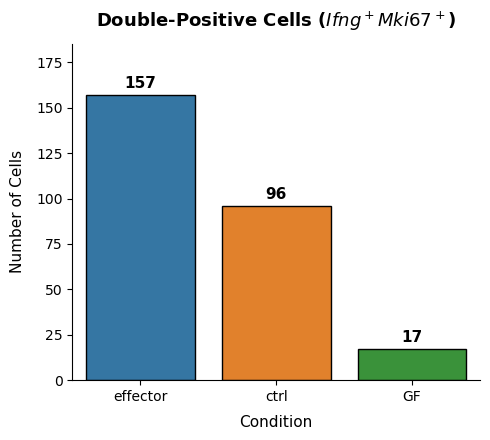

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load cell counts into DataFrame
df_counts = pd.DataFrame(
    {"condition": ["effector", "ctrl", "GF"], "count": [157, 96, 17]}
)

# 2. Set up publication-style plot
plt.figure(figsize=(5, 4.5))
palette = {"effector": "#2379B5", "ctrl": "#FF7F0E", "GF": "#2CA02C"}

ax = sns.barplot(
    data=df_counts,
    x="condition",
    y="count",
    palette=palette,
    edgecolor="black",
    linewidth=1,
)

# 3. Add text labels above each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

# 4. Styling
plt.title(
    "Double-Positive Cells ($Ifng^+ Mki67^+$)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Condition", fontsize=11, labelpad=8)
plt.ylabel("Number of Cells", fontsize=11, labelpad=8)
plt.ylim(0, max(df_counts["count"]) * 1.18)
sns.despine()

plt.tight_layout()
#plt.savefig("double_positive_cell_counts.png", dpi=300)
plt.show()

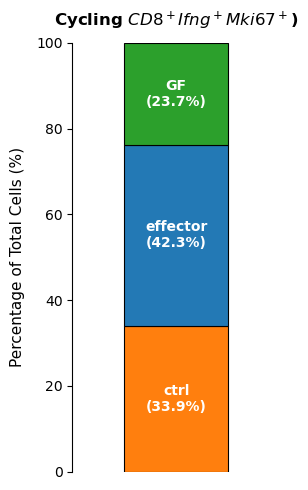

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract metadata from AnnData or MuData
obs_df = mdata["gex"].obs  # or adata.obs

# 2. Compute proportions for the entire dataset in a single column
# Count occurrences per condition and normalize to get percentages
prop_series = obs_df["condition"].value_counts(normalize=True) * 100

# Align order of conditions
condition_order = ["ctrl", "effector", "GF"]
prop_series = prop_series.reindex(
    [c for c in condition_order if c in prop_series.index]
)

# Convert to DataFrame with a single column name
df_single = pd.DataFrame(prop_series).T

# Color palette for conditions
palette = {"effector": "#2379B5", "ctrl": "#FF7F0E", "GF": "#2CA02C"}

# 3. Plot a single stacked bar chart
fig, ax = plt.subplots(figsize=(3, 5))

df_single.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[
        palette.get(c, "#333333") for c in df_single.columns
    ],  # Maps condition colors
    edgecolor="black",
    linewidth=0.8,
)

# Add percentage text labels inside the segments
cumulative = 0
for col in df_single.columns:
    val = df_single[col].values[0]
    if val > 3:  # Only add label if segment is large enough
        ax.text(
            0,
            cumulative + val / 2,
            f"{col}\n({val:.1f}%)",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=10,
        )
    cumulative += val

plt.title(  "Cycling $CD8^+ Ifng^+ Mki67^+$)", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Percentage of Total Cells (%)", fontsize=11, labelpad=8)
plt.xticks([])  # Remove x-axis tick label
plt.ylim(0, 100)
plt.legend().remove()  # Direct labels inside the bar replace the legend
sns.despine(bottom=True)  # Clean aesthetic

plt.tight_layout()
plt.savefig("figures/single_column_composition.svg", dpi=300)
plt.show()

In [45]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Build a dataframe for easy metric comparison
df_expr = pd.DataFrame(
    {
        "condition": cycling_ifng_mki67.obs["condition"],
        "Ifng": cycling_ifng_mki67[:, "Ifng"].X.toarray().flatten()
        if hasattr(cycling_ifng_mki67.X, "toarray")
        else cycling_ifng_mki67[:, "Ifng"].X.flatten(),
        "Mki67": cycling_ifng_mki67[:, "Mki67"].X.toarray().flatten()
        if hasattr(cycling_ifng_mki67.X, "toarray")
        else cycling_ifng_mki67[:, "Mki67"].X.flatten(),
    }
)

# Calculate mean expression per condition
mean_summary = df_expr.groupby("condition")[["Ifng", "Mki67"]].mean()
print("--- Mean Expression ---")
print(mean_summary)

# Run Mann-Whitney U test for both genes
for gene in ["Ifng", "Mki67"]:
    ctrl_vals = df_expr[df_expr["condition"] == "ctrl"][gene]
    effector_vals = df_expr[df_expr["condition"] == "effector"][gene]

    stat, pval = mannwhitneyu(effector_vals, ctrl_vals, alternative="two-sided")
    print(
        f"\n{gene} Statistical Comparison (effector vs. ctrl): p-value = {pval:.4e}"
    )

--- Mean Expression ---
               Ifng     Mki67
condition                    
GF         1.559371  0.162199
ctrl       1.476072  0.394740
effector   1.439964  0.297016

Ifng Statistical Comparison (effector vs. ctrl): p-value = 6.1821e-01

Mki67 Statistical Comparison (effector vs. ctrl): p-value = 3.1759e-01


/tmp/ipykernel_3256051/1293085408.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_summary = df_expr.groupby("condition")[["Ifng", "Mki67"]].mean()


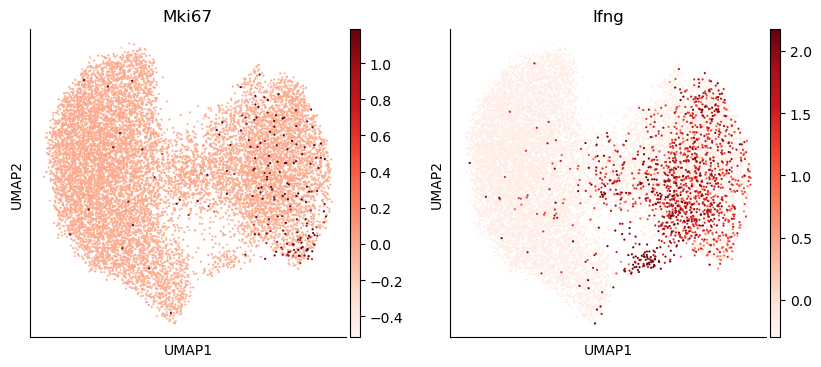

In [41]:
sc.pl.umap(cycling,color= ["Mki67","Ifng"], cmap="Reds", vmax="p99")

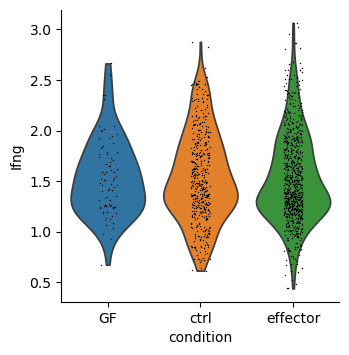

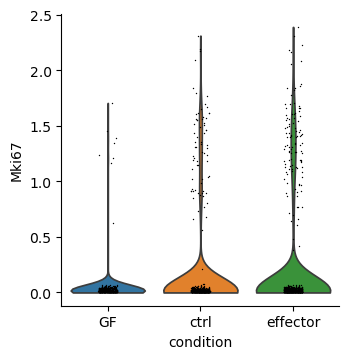

In [82]:
# Helper function to get positive cells for a specific gene
def get_pos_cells(adata, gene_name):
    expr = adata[:, gene_name].X
    mask = (expr.toarray().flatten() > 0) if hasattr(expr, "toarray") else (expr.flatten() > 0)
    return adata[mask].copy()

# Subset independently
ifng_pos_cells = get_pos_cells(cycling, "Ifng")
mki67_pos_cells = get_pos_cells(cycling, "Mki67")

# Plot each gene using its specific positive subset
sc.pl.violin(ifng_pos_cells, "Ifng", groupby="condition", cut=0)
sc.pl.violin(mki67_pos_cells, "Mki67", groupby="condition", cut=0)